<a href="https://colab.research.google.com/github/shelkekunal/Practice_of_ML/blob/main/IRIS_ANN%26CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
! pip install tensorflow keras

In [122]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [30]:
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
74,6.4,2.9,4.3,1.3,1
108,6.7,2.5,5.8,1.8,2
77,6.7,3.0,5.0,1.7,1
29,4.7,3.2,1.6,0.2,0
98,5.1,2.5,3.0,1.1,1


In [31]:
df.shape

(150, 5)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [38]:
x = df.drop('target',axis=1)
y = df['target']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120, 4)
(30, 4)
(120,)
(30,)


In [39]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

#ANN

In [106]:
ann_model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [107]:
ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [121]:
ann_history = ann_model.fit(x_train_scaled, y_train, epochs=50,
                    batch_size=10, validation_split=0.2)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8750 - loss: 0.3571 - val_accuracy: 0.8750 - val_loss: 0.4026
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8750 - loss: 0.3537 - val_accuracy: 0.8750 - val_loss: 0.3997
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8750 - loss: 0.3506 - val_accuracy: 0.8750 - val_loss: 0.3951
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8750 - loss: 0.3472 - val_accuracy: 0.8750 - val_loss: 0.3928
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8750 - loss: 0.3442 - val_accuracy: 0.8750 - val_loss: 0.3914
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8750 - loss: 0.3406 - val_accuracy: 0.8750 - val_loss: 0.3883
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8750 - loss: 0.3370 - val_accuracy: 0.8750 - val_loss: 0.3829
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8750 - loss: 0.3336 - val_accuracy: 0.8750 - val_lo

In [109]:
ann_loss, ann_accuracy = ann_model.evaluate(x_test_scaled, y_test,verbose=0)
print("Test Accuracy:", ann_accuracy)

Test Accuracy: 0.8999999761581421


In [120]:
ann_probs = ann_model.predict(x_test_scaled)
print(ann_probs[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
[0.00690285 0.51957536 0.4735218 ]


In [116]:
predicted_classes = np.argmax(ann_probs, axis=1)
print(predicted_classes)


[1 0 2 1 2 0 1 2 2 1 2 0 0 0 0 2 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


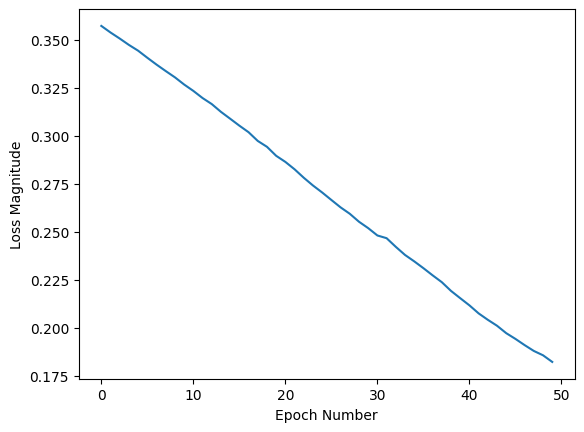

In [126]:
import matplotlib.pyplot as plt
plt.xlabel('Epoch Number')
plt.ylabel("Loss Magnitude")
plt.plot(ann_history.history['loss'])

#DNN

In [88]:
dnn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

In [89]:
dnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [102]:
dnn_history = dnn_model.fit(x_train_scaled, y_train, epochs=50,verbose=1,
                       batch_size=10, validation_split=0.2)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0092 - val_accuracy: 0.9167 - val_loss: 0.8446
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0109 - val_accuracy: 0.9167 - val_loss: 0.8558
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0101 - val_accuracy: 0.9167 - val_loss: 0.8291
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0097 - val_accuracy: 0.9167 - val_loss: 0.8543
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0092 - val_accuracy: 0.9167 - val_loss: 0.8457
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0087 - val_accuracy: 0.9167 - val_loss: 0.8641
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0084 - val_accuracy: 0.9167 - val_loss: 0.8663
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0090 - val_accuracy: 0.9167 - v

In [104]:
dnn_loss, dnn_accuracy = dnn_model.evaluate(x_test_scaled, y_test)
print("Test Accuracy:", dnn_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 1.0000 - loss: 0.0014
Test Accuracy: 1.0


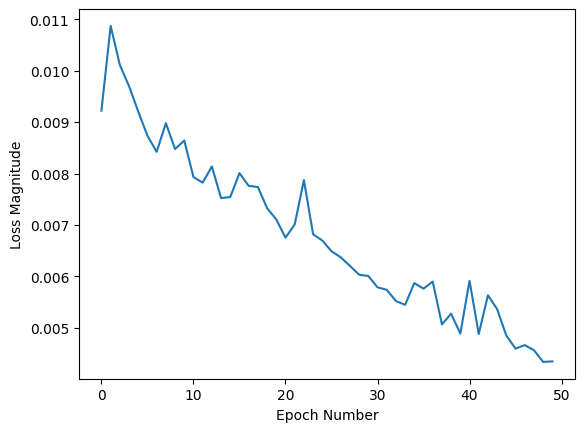

In [127]:
import matplotlib.pyplot as plt
plt.xlabel('Epoch Number')
plt.ylabel("Loss Magnitude")
plt.plot(dnn_history.history['loss'])

compare ANN and DNN

In [111]:
print("ANN Accuracy:", ann_accuracy)
print("DNN Accuracy:", dnn_accuracy)

ANN Accuracy: 0.8999999761581421
DNN Accuracy: 1.0


In [112]:
print("ANN Loss:", ann_loss)
print("DNN Loss:", dnn_loss)

ANN Loss: 0.33709952235221863
DNN Loss: 0.0014276086585596204


In [113]:
print(ann_model.summary())
print(dnn_model.summary())

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275 (1.08 KB)

 Trainable params: 91 (364.00 B)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 2,483 (9.70 KB)

 Trainable params: 827 (3.23 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,656 (6.47 KB)

None
